<a href="https://colab.research.google.com/github/benram2004-lab/mis433/blob/main/Final_text_analytics_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Analytics

Text analytics turns unstructured language into data that can be counted, compared, visualized, and modeled. Unlike many tabular datasets, text is high-dimensional: a single column of comments, reviews, emails, or news articles can contain thousands of unique words, phrases, spellings, and meanings.

The main challenge is representation. Before we can summarize or model text, we need to decide how to convert language into numeric features while preserving enough meaning for the task. In this notebook, we will practice common steps in that workflow: cleaning and exploring text, converting text to document-term matrices, finding frequent words, measuring word importance with TF-IDF, clustering similar documents, creating word clouds, and estimating sentiment.

# Load and explore data from csv

Source: https://www.kaggle.com/datasets/cloudy17/bob-dylan-songs/

**Context**
This dataset contains songs from years between 1961 to 2020 written by Bob Dylan.

**Content**
There are 4 columns:
* release_year - year when song was released first time,
* album - name of the album where track occurs,
* title - title of the song,
* lyrics - lyrics of the track

In [ ]:
import pandas as pd

# load dataset from csv
df = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/bob-dylan.csv')
df.head(3) # show the first three rows

,release_year,album,title,lyrics
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to..."
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ..."
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...


In [ ]:
# shape of the df: rows and columns
df.shape

(345, 4)

In [ ]:
# the data types of each column
df.dtypes

,0
release_year,int64
album,object
title,object
lyrics,object


In [ ]:
# Get a summary of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   release_year  345 non-null    int64 
 1   album         345 non-null    object
 2   title         345 non-null    object
 3   lyrics        345 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.9+ KB


In [ ]:
# Count the values of a column
df.release_year.value_counts()

,count
release_year,
1975,30
1965,22
1963,22
1964,21
1970,19
1966,15
1967,13
1981,13
1983,13


In [ ]:
df.album.value_counts()

,count
album,
"The Bootleg Series, Vol 1-3: Rare & Unreleased 1961-1991",37
The Basement Tapes,16
The Freewheelin',13
Blonde on Blonde,13
New Morning,12
John Wesley Harding,12
“Love and Theft”,12
Bringing It All Back Home,11
Under the Red Sky,10


In [ ]:
# Add a new column
df['decade'] = (df['release_year'] // 10) * 10
df.head()

,release_year,album,title,lyrics,decade
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960


In [ ]:
# String Operations
# Count the number of words in each song.

df['word_count'] = df['lyrics'].apply(lambda x: len(x.split()))
df.head()

,release_year,album,title,lyrics,decade,word_count
0,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Hard Times In New York Town,"Come you ladies and you gentlemen, a-listen to...",1960,353
1,1961,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Man on the street,"’ll sing you a song, ain’t very long\n\n’Bout ...",1960,158
2,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Talkin’ Bear Mountain Picnic Massacre Blues,I saw it advertised one day\n\nBear Mountain p...,1960,391
3,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...",Let Me Die in My Footsteps,I will not go down under the ground\n\n’Cause ...,1960,365
4,1962,"The Bootleg Series, Vol 1-3: Rare & Unreleased...","Rambling, Gambling Willie",Come around you rovin’ gamblers and a story I ...,1960,477


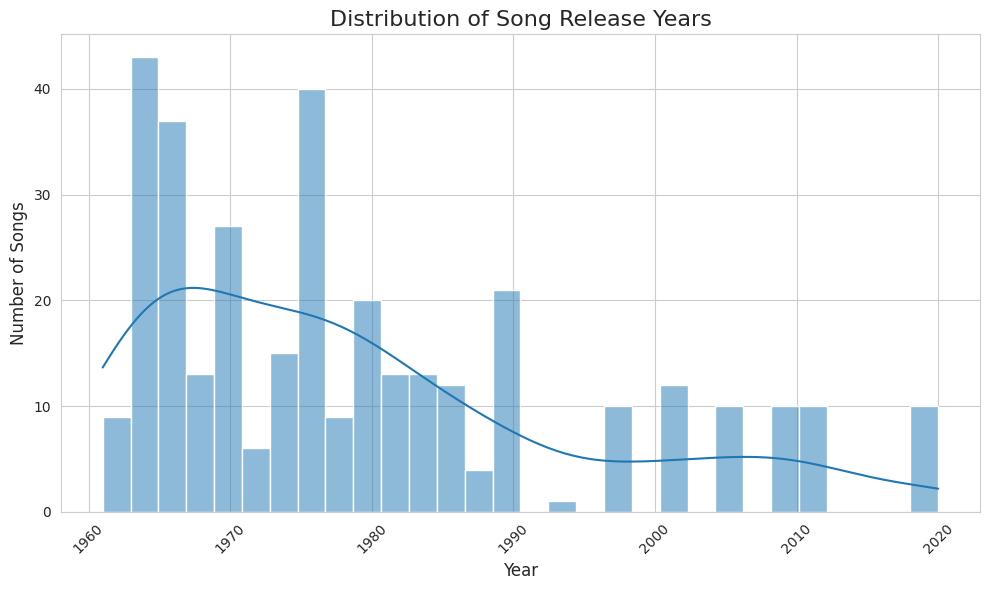

In [ ]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # Set a prettier style

plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.histplot(df['release_year'], bins=30, kde=True) # Use seaborn's histplot with kde for density estimate
plt.title('Distribution of Song Release Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Songs', fontsize=12)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## scikit-learn

Scikit-learn is one of the most popular Python packages for predictive data analysis. It includes tools for preprocessing text, building feature matrices, clustering documents, and training machine learning models.

https://scikit-learn.org/

If scikit-learn is not installed in your environment, uncomment and run the next cell.

In [ ]:
# !pip install scikit-learn

### Vectorization: Converting Text to Numeric Form

Text data must be converted into a numeric form before it can be used with machine learning algorithms. A common technique is `CountVectorizer`, which converts a collection of documents into a document-term matrix. Each row is a document, each column is a token, and each value is the number of times that token appears in that document.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Example using the 'lyrics' column of the Bob Dylan dataset
corpus = df['lyrics'].dropna().tolist()  # Assuming df is your DataFrame and dropping any missing values
vectorizer = CountVectorizer(stop_words='english')  # Remove common 'stop words'
X = vectorizer.fit_transform(corpus)

print(X.shape)  # Shows the shape of the matrix


(345, 7326)


In [ ]:
# Accessing the Vocabulary
vocabulary = vectorizer.vocabulary_

# Print the vocabulary dictionary (word: column index)
print(vocabulary)

{'come': 1220, 'ladies': 3508, 'gentlemen': 2630, 'listen': 3691, 'song': 5938, 'sing': 5777, 'right': 5267, 'think': 6491, 'wrong': 7278, 'just': 3423, 'little': 3698, 'glimpse': 2681, 'story': 6172, 'll': 3707, 'tell': 6439, 'bout': 662, 'east': 1989, 'coast': 1182, 'city': 1111, 'know': 3492, 'hard': 2896, 'times': 6558, 'livin': 3704, 'new': 4247, 'york': 7313, 'town': 6627, 'old': 4352, 'friendly': 2531, 'washington': 7031, 'heights': 2981, 'harlem': 2902, 'mighty': 4008, 'people': 4601, 'millin': 4015, 'kick': 3443, 'knock': 3484, 'long': 3731, 'ways': 7056, 'golden': 2706, 'gate': 2605, 'rockefeller': 5321, 'plaza': 4741, 'empire': 2045, 'state': 6108, 'mister': 4055, 'sets': 5607, 'high': 3011, 'bird': 501, 'says': 5488, 'word': 7229, 'country': 1373, 'mornin': 4113, 'tryin': 6734, 'job': 3371, 'work': 7232, 'stand': 6079, 'place': 4706, 'till': 6552, 'feet': 2270, 'begin': 438, 'hurt': 3161, 'got': 2727, 'lot': 3760, 'money': 4084, 'make': 3847, 'merry': 3984, 'nickel': 4256, 

In [ ]:
# Size of the vocabulary
len(vocabulary)

7326

In [ ]:
# View the first document's feature vector
document_index = 0
feature_vector_sparse = X.getrow(document_index)

# To convert to a dense array
feature_vector_dense = feature_vector_sparse.toarray()

print(feature_vector_dense)

[[0 0 0 ... 0 0 0]]


In [ ]:
# To View as a Readable Format

# Get feature names
feature_words = vectorizer.get_feature_names_out()

# Convert the sparse matrix row to a dense array
feature_vector_array = feature_vector_sparse.toarray().flatten()

# Create a dictionary mapping feature names to their values for the document
document_features = {feature_words[i]: int(feature_vector_array[i])
                     for i in range(len(feature_words)) if feature_vector_array[i] != 0}

print(document_features)

{'ay': 1, 'beat': 1, 'begin': 1, 'bird': 1, 'bit': 1, 'bought': 1, 'bout': 1, 'cal': 1, 'caves': 1, 'city': 9, 'cleaner': 1, 'coast': 1, 'come': 2, 'country': 1, 'dirt': 1, 'dream': 1, 'dust': 1, 'east': 1, 'empire': 2, 'feet': 2, 'ferry': 1, 'friendly': 1, 'gate': 1, 'gentlemen': 1, 'glimpse': 1, 'golden': 1, 'got': 2, 'hard': 7, 'harlem': 1, 'heights': 1, 'high': 1, 'hudson': 1, 'hurt': 1, 'island': 1, 'job': 1, 'just': 1, 'kick': 1, 'kind': 1, 'knock': 1, 'know': 1, 'ladies': 1, 'leave': 1, 'listen': 3, 'little': 1, 'livin': 7, 'll': 4, 'long': 1, 'lot': 1, 'make': 1, 'merry': 1, 'mighty': 2, 'millin': 1, 'mines': 1, 'minuet': 1, 'mister': 4, 'money': 1, 'mornin': 1, 'mountain': 1, 'ne': 1, 'new': 10, 'news': 1, 'newsy': 1, 'nickel': 1, 'oklahoma': 1, 'old': 4, 'paid': 1, 'people': 2, 'place': 1, 'plains': 1, 'plaza': 1, 'right': 2, 'rockefeller': 2, 'rocky': 1, 'sailin': 1, 'says': 1, 'sell': 1, 'sets': 1, 'sing': 1, 'smog': 1, 'song': 2, 'spread': 1, 'stand': 1, 'standin': 1, 'sta

In [ ]:
# Getting the Most Frequent Words

import numpy as np

# Sum up the counts of each word across all documents
word_counts = np.sum(X.toarray(), axis=0)  # X is the result of vectorizer.fit_transform(corpus)

# Map from feature index to word
feature_words = vectorizer.get_feature_names_out()

# Combine counts and words into a dictionary, ensuring counts are Python integers
word_count_dict = {word: int(count) for word, count in zip(feature_words, word_counts)}

# Sort the dictionary by counts in descending order to get the most frequent words
sorted_word_count = sorted(word_count_dict.items(), key=lambda x: x[1], reverse=True)

# Print the top N most frequent words
top_n_words = 20  # You can adjust N as needed
print(sorted_word_count[:top_n_words])

[('don', 553), ('like', 496), ('just', 477), ('got', 465), ('ll', 451), ('know', 418), ('love', 301), ('gonna', 296), ('man', 287), ('time', 273), ('ve', 273), ('ain', 271), ('said', 265), ('come', 253), ('say', 252), ('oh', 241), ('tell', 219), ('baby', 207), ('way', 195), ('day', 192)]


/tmp/ipykernel_34754/531371955.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')


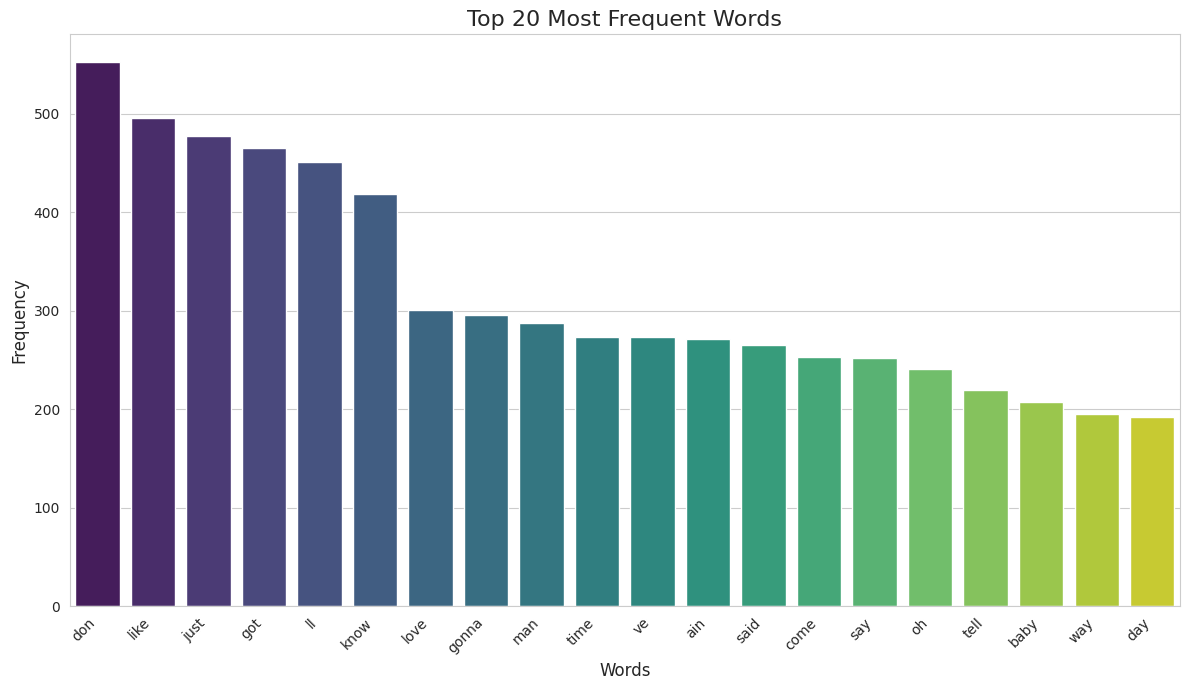

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract words and counts from the sorted_word_count list
words = [item[0] for item in sorted_word_count[:top_n_words]]
counts = [item[1] for item in sorted_word_count[:top_n_words]]

# Create a DataFrame for easier plotting with seaborn
most_frequent_words_df = pd.DataFrame({'Word': words, 'Count': counts})

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Word', y='Count', data=most_frequent_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### TF-IDF: Weighing Word Importance

TF-IDF stands for term frequency-inverse document frequency. It gives higher scores to words that appear often in a particular document but not too often across the entire collection. This helps reduce the influence of common words and highlight words that are more distinctive for a song.

In practice, TF-IDF is often more useful than raw word counts for comparing documents because it balances local importance with overall rarity.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(X_tfidf.shape)


(345, 7326)


### Clustering: Grouping Similar Songs

With the numeric representations, you can now perform clustering to group similar songs.

**K-means** is a popular algorithm that can partition a set of data points into K groups, where K is predefined.

In [ ]:
from sklearn.cluster import KMeans

# Using TF-IDF vectors for clustering
kmeans = KMeans(n_clusters=5, random_state=0)  # Assuming we want to cluster into 5 groups
kmeans.fit(X_tfidf)

# Print cluster labels for each song
print(kmeans.labels_)

# Count the number of songs in each cluster (from KMeans)
cluster_counts = np.bincount(kmeans.labels_)

print("KMeans Cluster Sizes:")
for i, count in enumerate(cluster_counts):
    print(f"Cluster {i}: {count} songs")

[3 4 3 3 4 1 3 3 3 4 3 2 2 3 1 3 3 3 4 3 1 3 3 1 1 4 4 4 4 3 4 3 3 4 0 3 4
 1 1 0 1 3 3 3 3 1 0 3 1 4 3 3 1 3 2 1 3 3 3 3 3 3 4 0 1 3 4 1 1 1 3 1 4 3
 4 1 3 2 3 4 3 1 3 1 1 3 0 2 3 4 1 4 3 2 4 4 3 1 1 2 4 3 3 1 1 2 0 3 3 3 3
 4 4 0 4 4 3 3 3 2 0 3 0 4 4 0 1 1 2 3 3 0 3 3 3 3 1 3 0 3 1 1 3 2 3 3 1 2
 1 2 1 1 3 0 4 2 4 4 1 0 3 3 3 1 1 3 0 3 0 4 1 4 4 1 3 3 3 4 1 3 4 4 0 2 4
 3 4 2 4 0 1 3 3 1 4 1 3 1 3 1 3 1 1 0 4 3 1 1 3 1 4 1 3 2 1 0 2 3 1 1 1 0
 3 3 4 1 3 3 0 3 3 3 0 2 3 2 1 3 1 3 1 1 4 3 4 3 1 1 1 3 2 3 3 3 0 3 0 4 1
 3 3 3 1 4 1 1 1 3 4 4 3 3 4 3 3 3 1 3 3 4 3 0 4 3 3 3 3 3 2 3 3 2 3 3 3 3
 3 3 3 4 3 1 3 3 3 3 3 3 1 3 1 1 3 1 3 1 2 1 3 3 3 3 1 1 3 3 3 3 3 2 3 4 3
 1 1 1 4 2 3 3 3 3 3 2 3]
KMeans Cluster Sizes:
Cluster 0: 26 songs
Cluster 1: 82 songs
Cluster 2: 27 songs
Cluster 3: 154 songs
Cluster 4: 56 songs


**Hierarchical Clustering** is a different algorithm that agglomeratively groups similar objects into clusters, eventually forming a tree (hierarchy) of clusters.

Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):


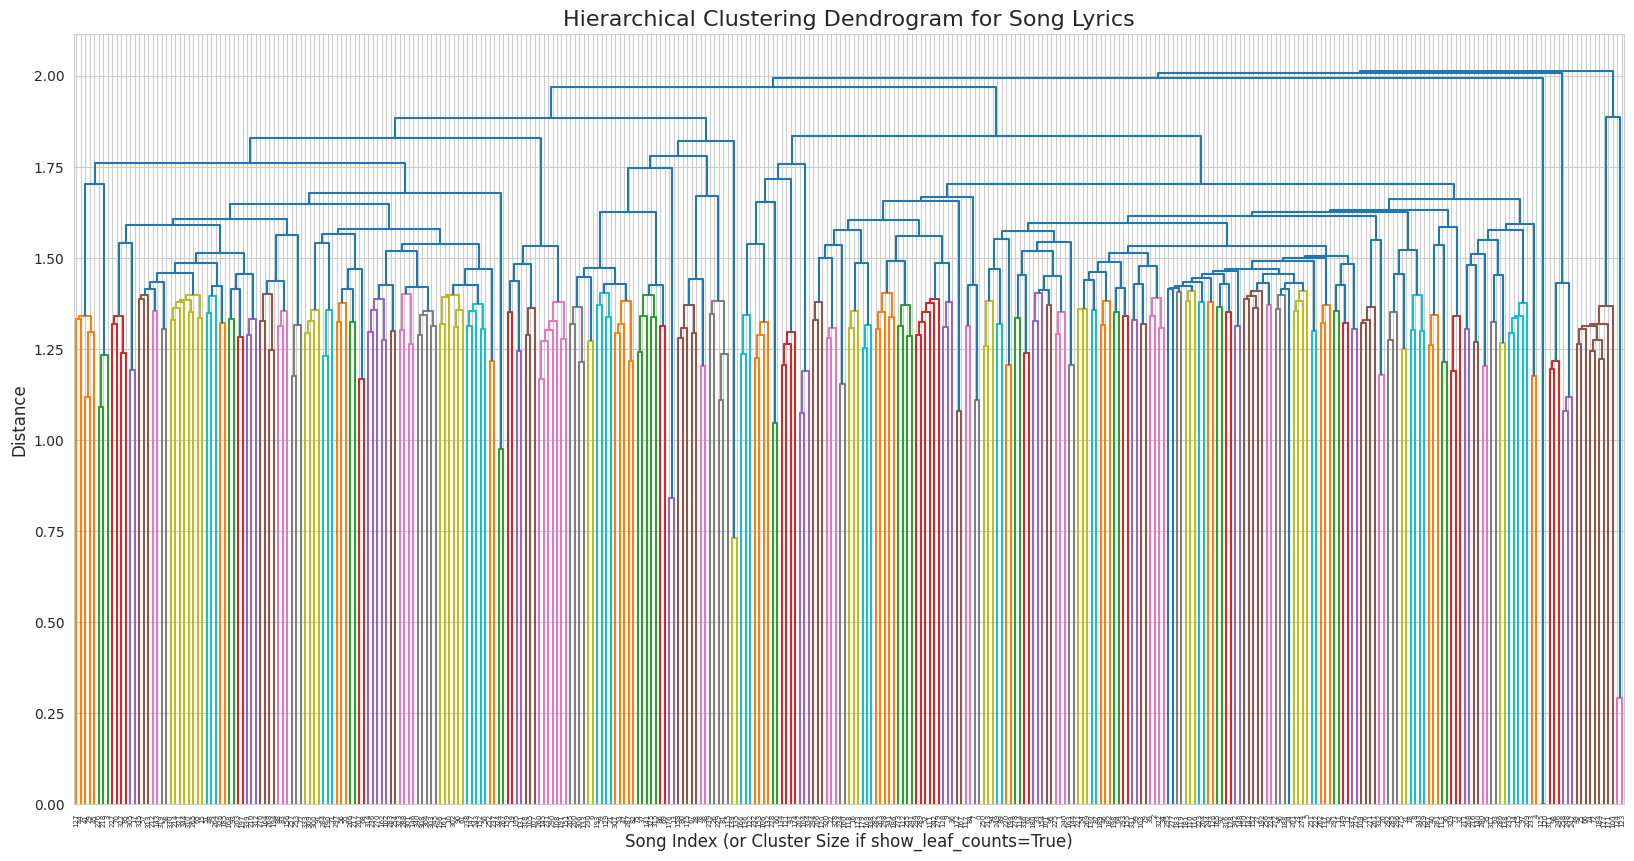

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

print("Visualizing Clusters as a Tree (Dendrogram using Hierarchical Clustering):")

# Perform hierarchical clustering on the TF-IDF vectors
# 'ward' linkage minimizes the variance of the clusters being merged.
# You can choose other methods like 'complete', 'average', 'single'.
linked = linkage(X_tfidf.toarray(), 'ward')

# Plot the dendrogram
plt.figure(figsize=(20, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram for Song Lyrics', fontsize=16)
plt.xlabel('Song Index (or Cluster Size if show_leaf_counts=True)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.show()

### Create a Word Cloud

A word cloud is a quick visual summary of common words. It is easy to read, but it should be treated as exploratory rather than analytical because it does not show exact counts or account for context.

In [ ]:
# Install wordcloud package
#!pip install --upgrade wordcloud

In [ ]:
# You may need to run this too.
#!pip install --upgrade Pillow

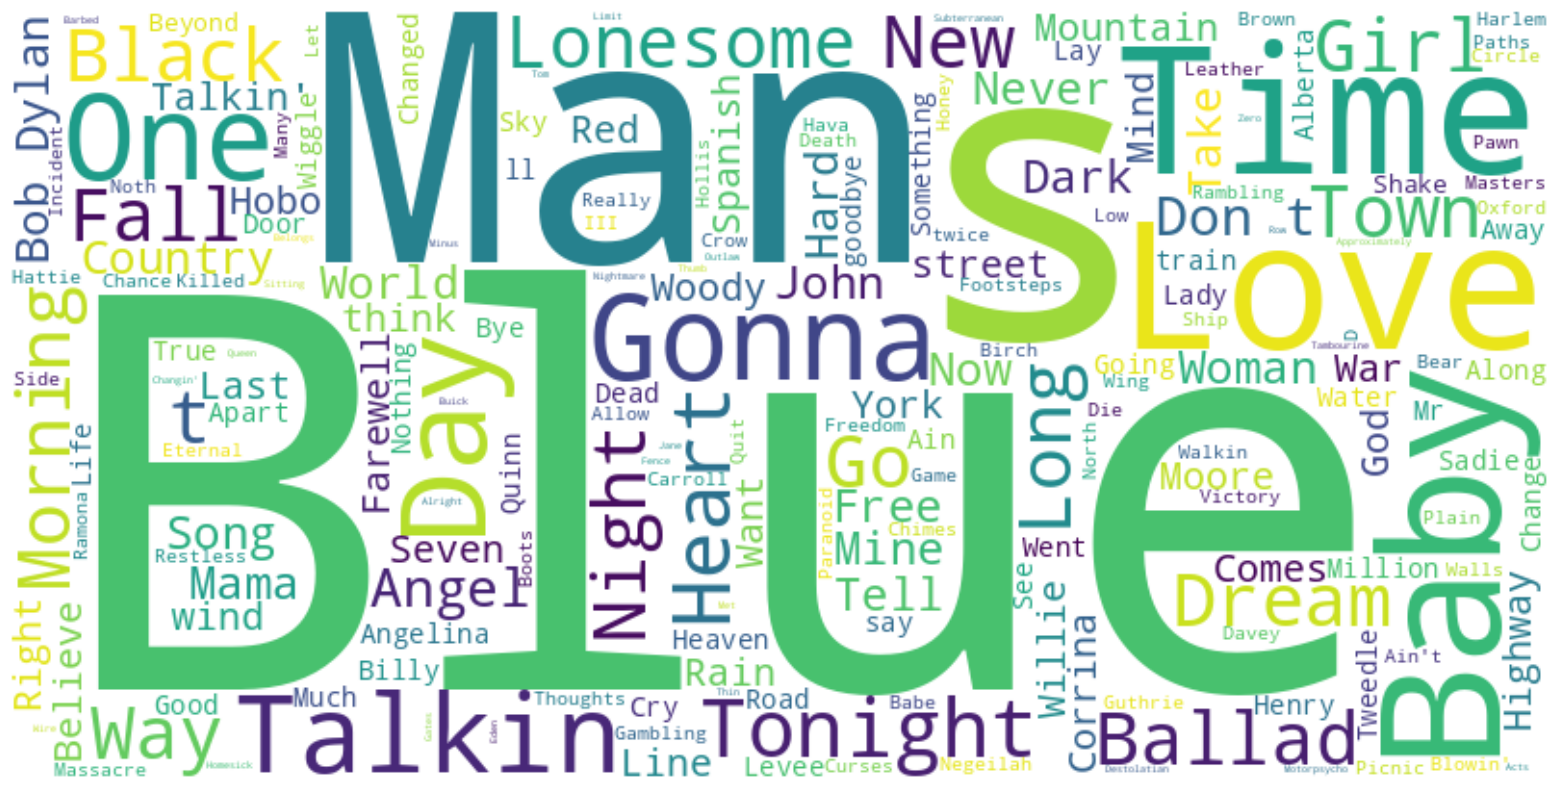

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all the text in the 'title' column into a single string
all_titles_text = " ".join(title for title in df['title'])

# Generate a word cloud image
wordcloud = WordCloud(background_color='white', width=800, height=400).generate(all_titles_text)

# Display the generated image
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Sentiment Analysis with a Pre-trained Model

For a simple sentiment analysis, you can use a pre-trained model from libraries such as TextBlob to estimate the sentiment score expressed in text.

TextBlob: https://textblob.readthedocs.io/en/dev/

In [ ]:
# Install TextBlob
!pip install textblob

In [ ]:
# This example uses TextBlob for sentiment analysis
from textblob import TextBlob

# Sample usage with the first five song's lyrics
for i in range(5):
    title = df['title'].iloc[i]
    lyrics = df['lyrics'].iloc[i]
    blob = TextBlob(lyrics)
    score = blob.sentiment.polarity
    print(f"{title}\t{lyrics[:25]}...\t{score}")

Hard Times In New York Town	Come you ladies and you g...	0.011896504729838058
Man on the street	’ll sing you a song, ain’...	-0.0692063492063492
Talkin’ Bear Mountain Picnic Massacre Blues	I saw it advertised one d...	0.14592111592111595
Let Me Die in My Footsteps	I will not go down under ...	-0.04433742183742184
Rambling, Gambling Willie	Come around you rovin’ ga...	-0.014664989664989669


## Exercises

Try these exercises to practice adapting the workflow above. Start by writing the code yourself, then compare your result with a partner or instructor.

In [ ]:
# Exercise 1: Find the top 10 frequent words in Dylan's songs for each decade.
# Hint: loop through text_df.groupby('decade'), then fit a CountVectorizer to each decade's lyrics.

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# group dataframe by decade
decades = sorted(df['decade'].unique())

# dictionary to store words
top_words_by_decade = {}

for decade in decades:
    print(f"\n--- Decade: {decade}s ---")
    # Filter the DataFrame for the current decade
    decade_df = df[df['decade'] == decade]

    # Combine all lyrics for the current decade into a single string
    decade_corpus = decade_df['lyrics'].dropna().tolist()

    if not decade_corpus:
        print("No lyrics found for this decade.")
        continue

    # Initialize CountVectorizer for this decade, remove if not mentioned in 5
    vectorizer = CountVectorizer(stop_words='english', min_df=5)

    # fit and transform lyrics per decade
    X_decade = vectorizer.fit_transform(decade_corpus)

    # sum count
    word_counts_decade = X_decade.sum(axis=0)

    #feature names
    feature_words_decade = vectorizer.get_feature_names_out()

    #create a dictionary
    word_count_dict_decade = {word: int(count) for word, count in zip(feature_words_decade, word_counts_decade.tolist()[0])}

    #sort words by count
    sorted_word_count_decade = sorted(word_count_dict_decade.items(), key=lambda x: x[1], reverse=True)

    # store top ten most frequent
    top_10 = sorted_word_count_decade[:10]
    top_words_by_decade[decade] = top_10

    #print top 10
    for word, count in top_10:
        print(f"  {word}: {count}")



--- Decade: 1960s ---
  just: 182
  don: 152
  like: 142
  ll: 138
  got: 135
  ain: 127
  know: 126
  said: 103
  come: 88
  man: 84

--- Decade: 1970s ---
  like: 146
  don: 140
  gonna: 125
  just: 113
  said: 98
  know: 94
  ll: 91
  oh: 90
  time: 89
  got: 85

--- Decade: 1980s ---
  don: 135
  got: 110
  know: 105
  like: 97
  just: 96
  love: 87
  man: 67
  time: 64
  ll: 60
  baby: 59

--- Decade: 1990s ---
  like: 42
  don: 36
  got: 31
  know: 27
  til: 27
  just: 26
  gonna: 21
  love: 21
  ll: 19
  ve: 19

--- Decade: 2000s ---
  got: 77
  don: 57
  ll: 52
  gonna: 51
  just: 44
  know: 44
  day: 41
  say: 41
  ain: 39
  good: 39

--- Decade: 2010s ---
  ll: 44
  long: 32
  way: 20
  day: 16
  heart: 16
  right: 13
  night: 12
  away: 10
  blood: 10
  good: 9

--- Decade: 2020s ---
  play: 70
  ll: 47
  don: 26
  like: 23
  got: 19
  tell: 19
  ve: 19
  sing: 18
  mind: 17
  way: 17


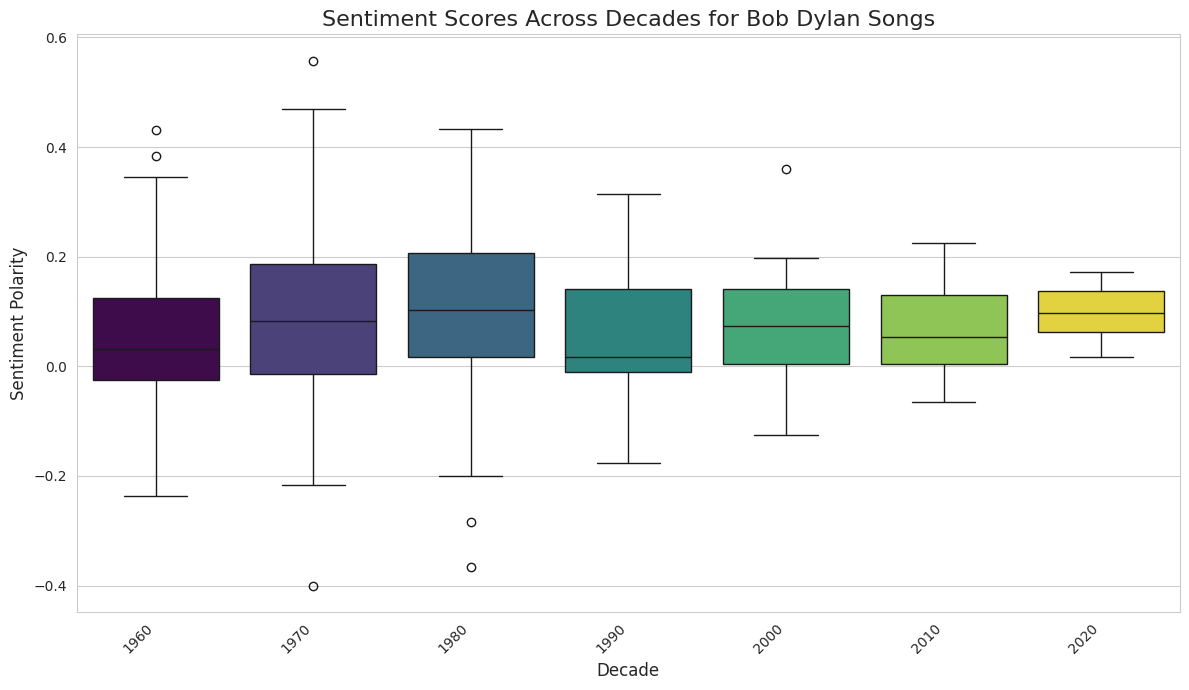

In [ ]:
# Exercise 2: Create a boxplot showing sentiment scores across decades.
# Hint: use x='decade' and y='sentiment_polarity' with sns.boxplot().
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# calculute sentiment
df['sentiment_polarity'] = df['lyrics'].apply(lambda lyrics: TextBlob(lyrics).sentiment.polarity if pd.notna(lyrics) else 0.0)

sns.set_style('whitegrid')

plt.figure(figsize=(12, 7))
sns.boxplot(x='decade', y='sentiment_polarity', data=df, palette='viridis', hue='decade', legend=False)
plt.title('Sentiment Scores Across Decades for Bob Dylan Songs', fontsize=16)
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Working with Text Data from an API

Many API responses contain text data. For instance, the [NewsAPI](https://newsapi.org/) searches articles and breaking-news headlines from news sources and blogs across the web.

In this section, we will search recent news articles and convert the results into a DataFrame for text analysis.

To use the NewsAPI, you'll need an API key. It's recommended to store your API key securely in Colab's secrets manager under the "🔑" icon in the left panel. Name the secret `NEWS_API_KEY`.

In [ ]:
from google.colab import userdata

NEWS_API_KEY = userdata.get('NEWS_API_KEY')
print(f"API Key: {NEWS_API_KEY}")

API Key: 34e0481e1b35482d919fc0bf5bbe636f


In [ ]:
import datetime

# Get today's date
today = datetime.date.today()

# Calculate the date three days ago
three_days_ago = today - datetime.timedelta(days=3)

# Format the date for the API request (YYYY-MM-DD)
from_param = three_days_ago.strftime('%Y-%m-%d')

print(f"Fetching news from: {from_param} to {today.strftime('%Y-%m-%d')}")

Fetching news from: 2026-05-29 to 2026-06-01


In [ ]:
import requests
import pandas as pd # Import pandas for DataFrame

query = input("Please enter your search query for news articles: ")
print(f"Searching for articles related to: {query}")

# NewsAPI endpoint for all articles
url = 'https://newsapi.org/v2/everything'

# Parameters for the request
params = {
    'pageSize': 100,    # Max number of articles to retrieve per request for 'everything' endpoint
    'apiKey': NEWS_API_KEY,
    'q': query, # The search query
    'from': from_param, # Start date for the search (already calculated)
    'to': today.strftime('%Y-%m-%d'), # End date for the search (today)
    'language': 'en' # Filter for English language articles
}

try:
    response = requests.get(url, params=params)
    response.raise_for_status() # Raise an exception for HTTP errors
    data = response.json()

    print("Successfully fetched news articles.")

    articles_data = []
    for article in data['articles']:
        source_name = article.get('source', {}).get('name', 'N/A')
        articles_data.append({
            'title': article.get('title'),
            'author': article.get('author'),
            'source': source_name,
            'description': article.get('description'),
            'date': article.get('publishedAt')
        })

    news_df = pd.DataFrame(articles_data)

    print(f"Total articles retrieved and saved to DataFrame: {len(news_df)}")
    print(f"Total results matching query (available from API): {data['totalResults']}")
    display(news_df.head())

except requests.exceptions.RequestException as e:
    print(f"Error fetching news: {e}")
    if response.status_code == 401:
        print("Unauthorized: Check your API key.")
    elif response.status_code == 429:
        print("Too Many Requests: You may have hit your API rate limit.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Please enter your search query for news articles: politics
Searching for articles related to: politics
Successfully fetched news articles.
Total articles retrieved and saved to DataFrame: 99
Total results matching query (available from API): 775


,title,author,source,description,date
0,The Texas Senate Race Is Going to Be Pure Slime,Jim Newell,Slate Magazine,It was another banner week of politics in Amer...,2026-05-30T09:45:00Z
1,SpaceX gets $4 billion contract to build missi...,Emma Roth,The Verge,The Pentagon awarded SpaceX a $4.16 billion co...,2026-05-29T21:48:52Z
2,What it means to be a man is a theme in Texas ...,Danielle Kurtzleben,NPR,Soon after winning the Texas Republican Senate...,2026-05-30T09:00:00Z
3,"Emilia Clarke Can ""Finally"" Feel Grateful Abou...",Matt Schimkowitz,Jezebel,"Since 2007, Jezebel has been the Internet's mo...",2026-05-29T14:30:51Z
4,Louisiana Approves New Voting Map Eliminating ...,Josh Jackson,Jezebel,"Since 2007, Jezebel has been the Internet's mo...",2026-05-29T16:39:47Z


### Analyze the Text in the News Articles

What questions can we ask about this dataset?

- Which words appear most often in article titles or descriptions?
- Do different sources use different language for the same topic?
- How does sentiment vary across articles or sources?
- Are there clusters of articles that focus on different subtopics?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Ensure news_df exists and 'title' column is present
if 'news_df' in locals() and isinstance(news_df, pd.DataFrame) and 'title' in news_df.columns:
    # Combine all titles into a single corpus, handling potential NaN values
    news_titles_corpus = news_df['title'].dropna().tolist()

    if not news_titles_corpus:
        print("No titles found in news_df for clustering.")
    else:
        # Initialize TfidfVectorizer
        tfidf_vectorizer_news = TfidfVectorizer(stop_words='english')

        # Fit and transform the news titles
        X_news_tfidf = tfidf_vectorizer_news.fit_transform(news_titles_corpus)

        # Perform K-Means clustering (choosing an arbitrary number of clusters, e.g., 5)
        num_clusters = 5
        kmeans_news = KMeans(n_clusters=num_clusters, random_state=0, n_init=10) # n_init for robust centroid initialization
        kmeans_news.fit(X_news_tfidf)

        # Add cluster labels to the news_df (aligning with the original, non-null titles)
        labels_series = pd.Series(kmeans_news.labels_, index=news_df['title'].dropna().index)

        # Assign these labels back to the 'title_cluster' column in news_df

        news_df['title_cluster'] = labels_series.reindex(news_df.index)

        # Count the number of articles in each cluster
        cluster_counts_news = news_df['title_cluster'].value_counts().sort_index()

        print("K-Means Clustering on News Article Titles:")
        print(f"Number of clusters: {num_clusters}")
        print("\nCluster Sizes:")
        for cluster_id, count in cluster_counts_news.items():
            print(f"Cluster {int(cluster_id)}: {count} articles")

        print("\nFirst 5 rows of news_df with new 'title_cluster' column:")
        display(news_df.head())


else:
    print("DataFrame 'news_df' not found or 'title' column is missing. Please make sure to load your news data first.")

K-Means Clustering on News Article Titles:
Number of clusters: 5

Cluster Sizes:
Cluster 0: 74 articles
Cluster 1: 4 articles
Cluster 2: 5 articles
Cluster 3: 11 articles
Cluster 4: 5 articles

First 5 rows of news_df with new 'title_cluster' column:


,title,author,source,description,date,title_lower,description_lower,title_cluster
0,The Texas Senate Race Is Going to Be Pure Slime,Jim Newell,Slate Magazine,It was another banner week of politics in Amer...,2026-05-30T09:45:00Z,the texas senate race is going to be pure slime,it was another banner week of politics in amer...,0
1,SpaceX gets $4 billion contract to build missi...,Emma Roth,The Verge,The Pentagon awarded SpaceX a $4.16 billion co...,2026-05-29T21:48:52Z,spacex gets $4 billion contract to build missi...,the pentagon awarded spacex a $4.16 billion co...,0
2,What it means to be a man is a theme in Texas ...,Danielle Kurtzleben,NPR,Soon after winning the Texas Republican Senate...,2026-05-30T09:00:00Z,what it means to be a man is a theme in texas ...,soon after winning the texas republican senate...,0
3,"Emilia Clarke Can ""Finally"" Feel Grateful Abou...",Matt Schimkowitz,Jezebel,"Since 2007, Jezebel has been the Internet's mo...",2026-05-29T14:30:51Z,"emilia clarke can ""finally"" feel grateful abou...","since 2007, jezebel has been the internet's mo...",0
4,Louisiana Approves New Voting Map Eliminating ...,Josh Jackson,Jezebel,"Since 2007, Jezebel has been the Internet's mo...",2026-05-29T16:39:47Z,louisiana approves new voting map eliminating ...,"since 2007, jezebel has been the internet's mo...",0


In [ ]:
#which words appear most often in article titles
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

#combine titles
news_titles_corpus = news_df['title'].dropna().tolist()

#initilizae count vector to eliminate non english words
news_title_vectorizer = CountVectorizer(stop_words='english')

#fit the vectorizer to the titles and transform them into a document-term matrix
X_news_titles = news_title_vectorizer.fit_transform(news_titles_corpus)

#sum up the counts
word_counts_news_titles = np.sum(X_news_titles.toarray(), axis=0)

#get actual words
feature_words_news_titles = news_title_vectorizer.get_feature_names_out()

#Create Dictionary
word_count_dict_news_titles = {word: int(count) for word, count in zip(feature_words_news_titles, word_counts_news_titles)}

#Sort the dictionary by counts in descending order to find the most frequent words
sorted_word_count_news_titles = sorted(word_count_dict_news_titles.items(), key=lambda x: x[1], reverse=True)

#define top 20 words to display
top_n_words_news_titles = 20

print(f"Top {top_n_words_news_titles} most frequent words in news article titles:")
for word, count in sorted_word_count_news_titles[:top_n_words_news_titles]:
    print(f"- {word}: {count}")

Top 20 most frequent words in news article titles:
- trump: 12
- senate: 7
- texas: 6
- mamdani: 5
- politics: 5
- race: 5
- challenger: 4
- day: 4
- democrats: 4
- political: 4
- center: 3
- finally: 3
- judge: 3
- kennedy: 3
- maga: 3
- man: 3
- new: 3
- party: 3
- paxton: 3
- people: 3


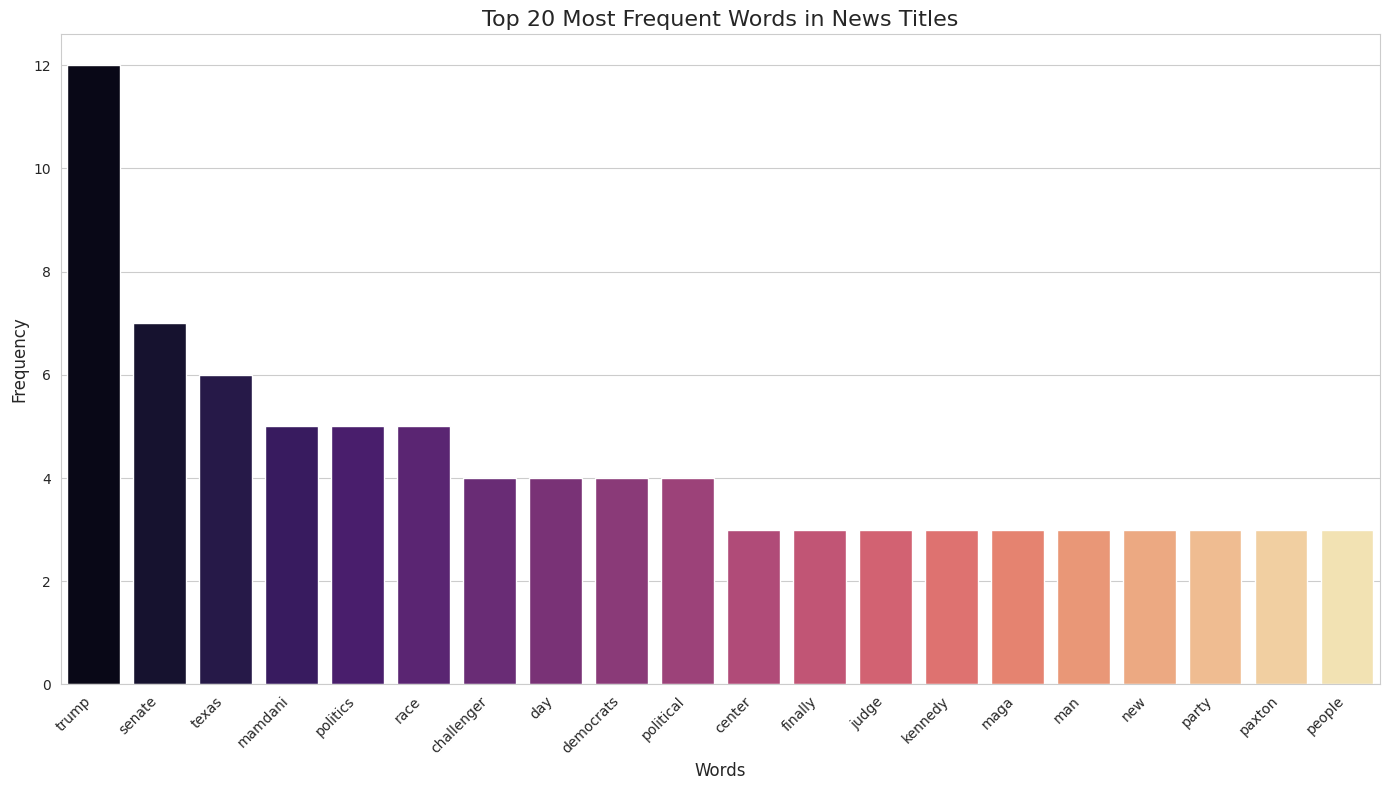

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#extract words for plotting
words_plot = [item[0] for item in sorted_word_count_news_titles[:top_n_words_news_titles]]
counts_plot = [item[1] for item in sorted_word_count_news_titles[:top_n_words_news_titles]]

#create dataframe
most_frequent_news_words_df = pd.DataFrame({'Word': words_plot, 'Count': counts_plot})


plt.figure(figsize=(14, 8))
sns.barplot(x='Word', y='Count', data=most_frequent_news_words_df, palette='magma', hue='Word', legend=False)
plt.title(f'Top {top_n_words_news_titles} Most Frequent Words in News Titles', fontsize=16)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
#how many articles are talking about the world cup
import pandas as pd

# Ensure news_df exists and has 'title' and 'description' columns
if 'news_df' in locals() and isinstance(news_df, pd.DataFrame):
    if 'title' in news_df.columns and 'description' in news_df.columns:
        # Convert title and description columns to string type and lowercase for case-insensitive search
        # Fill NaN values with empty strings to avoid errors during string operations
        news_df['title_lower'] = news_df['title'].astype(str).str.lower().fillna('')
        news_df['description_lower'] = news_df['description'].astype(str).str.lower().fillna('')

        #count articles with world cup mentioned in title or descritpion
        world_cup_articles_count = news_df[
            (news_df['title_lower'].str.contains('world cup')) |
            (news_df['description_lower'].str.contains('world cup'))
        ].shape[0]

        print(f"Number of articles mentioning 'world cup': {world_cup_articles_count}")
    else:
        print("DataFrame 'news_df' does not contain 'title' or 'description' columns.")
else:
    print("DataFrame 'news_df' not found. Please make sure to load your news data first.")


Number of articles mentioning 'world cup': 1


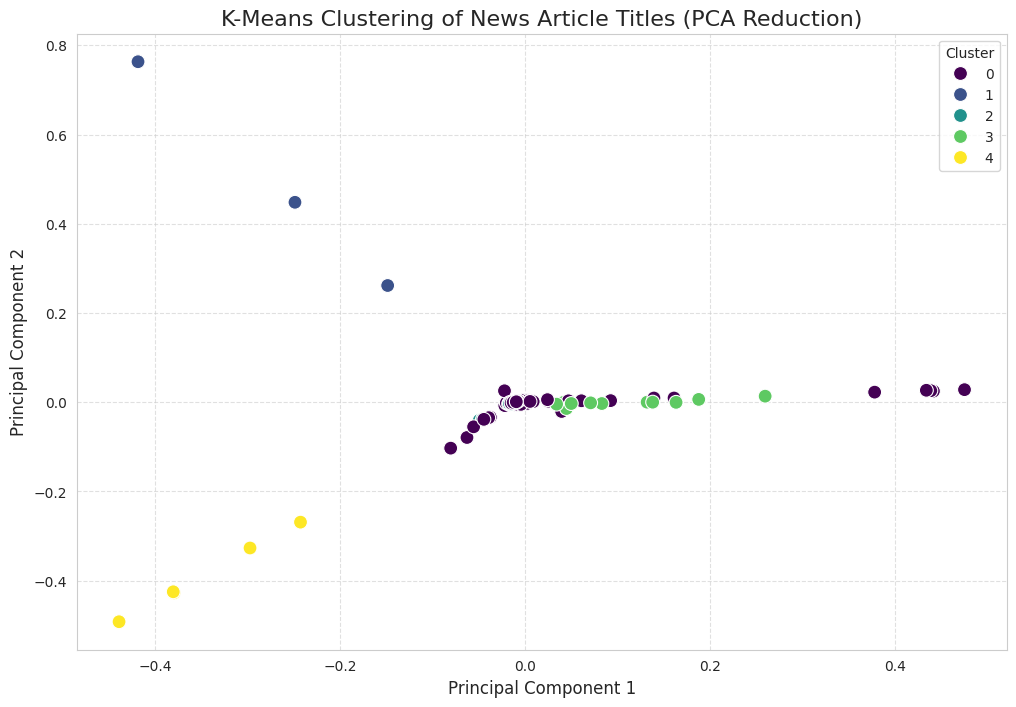

In [ ]:
#Are there clusters of articles that focus on different subtopics?
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#ensure newsdf exists
if 'news_df' in locals() and isinstance(news_df, pd.DataFrame) and \
   'X_news_tfidf' in locals() and hasattr(X_news_tfidf, 'shape') and \
   'kmeans_news' in locals() and hasattr(kmeans_news, 'labels_'):

    # Apply PCA to reduce dimensions for plotting.
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_news_tfidf.toarray())
     # Convert sparse to dense for PCA

    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'PC1': components[:, 0],
        'PC2': components[:, 1],
        'Cluster': kmeans_news.labels_
    })

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='PC1',
        y='PC2',
        hue='Cluster',
        palette='viridis', # Choose a color palette
        data=plot_df,
        legend='full',
        s=100 # Adjust point size
    )
    plt.title('K-Means Clustering of News Article Titles (PCA Reduction)', fontsize=16)
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("Required variables for plotting (news_df, X_news_tfidf, kmeans_news) not found or improperly structured.")